# Customer Churn Prediction using Random Forest
### End-to-End Machine Learning & Deployment — B.Tech Gen AI (2nd Semester)
**Dataset:** customer_churn.csv | **Algorithm:** Random Forest Classifier

## 1. Introduction

**Customer Churn** refers to the phenomenon where customers stop doing business with a company.

**Why does churn prediction matter?**
- Retaining an existing customer costs **5–7× less** than acquiring a new one.
- Early identification of at-risk customers allows targeted retention campaigns.
- Reducing churn by even 5% can increase profit by 25–95%.

**Why Random Forest?**
- Handles mixed data types (categorical + numeric) without heavy preprocessing.
- Robust to outliers through bagging (averaging multiple decision trees).
- Provides built-in **feature importance** scores for model interpretability.
- Requires minimal hyperparameter tuning for strong baseline results.

## 2. Importing Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
import joblib

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 3. Data Loading and Exploration

In [3]:
df = pd.read_csv('customer_churn.csv')
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Dataset Shape: 954 rows × 7 columns


,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,34,No,Middle Income,6,No,Yes,0
1,34,Yes,Low Income,5,Yes,No,1
2,37,No,Middle Income,3,Yes,No,0
3,30,No,Middle Income,2,No,No,0
4,30,No,Low Income,1,No,No,0
5,27,Yes,High Income,1,No,Yes,1
6,34,No,Middle Income,4,Yes,Yes,0
7,34,No,Low Income,2,Yes,No,1
8,30,No,Low Income,3,No,Yes,0
9,36,Yes,High Income,1,No,No,1


In [4]:
print("=== Data Types & Non-Null Counts ===")
df.info()

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         954 non-null    int64 
 1   FrequentFlyer               954 non-null    object
 2   AnnualIncomeClass           954 non-null    object
 3   ServicesOpted               954 non-null    int64 
 4   AccountSyncedToSocialMedia  954 non-null    object
 5   BookedHotelOrNot            954 non-null    object
 6   Target                      954 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 52.3+ KB


In [5]:
print("=== Summary Statistics ===")
df.describe(include='all')

=== Summary Statistics ===


,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
count,954.000000,954,954,954.000000,954,954,954.000000
unique,NaN,3,3,NaN,2,2,NaN
top,NaN,No,Middle Income,NaN,No,No,NaN
freq,NaN,608,409,NaN,594,576,NaN
mean,32.109015,NaN,NaN,2.437107,NaN,NaN,0.234801
std,3.337388,NaN,NaN,1.606233,NaN,NaN,0.424097
min,27.000000,NaN,NaN,1.000000,NaN,NaN,0.000000
25%,30.000000,NaN,NaN,1.000000,NaN,NaN,0.000000
50%,31.000000,NaN,NaN,2.000000,NaN,NaN,0.000000
75%,35.000000,NaN,NaN,4.000000,NaN,NaN,0.000000


In [6]:
print("=== Missing / Null Values ===")
print(df.isnull().sum())

print("\n=== Unique Values per Column ===")
for col in df.columns:
    print(f"  {col}: {list(df[col].unique()[:6])}{'...' if df[col].nunique() > 6 else ''}")

=== Missing / Null Values ===
Age                           0
FrequentFlyer                 0
AnnualIncomeClass             0
ServicesOpted                 0
AccountSyncedToSocialMedia    0
BookedHotelOrNot              0
Target                        0
dtype: int64

=== Unique Values per Column ===
  Age: [np.int64(34), np.int64(37), np.int64(30), np.int64(27), np.int64(36), np.int64(28)]...
  FrequentFlyer: ['No', 'Yes', 'No Record']
  AnnualIncomeClass: ['Middle Income', 'Low Income', 'High Income']
  ServicesOpted: [np.int64(6), np.int64(5), np.int64(3), np.int64(2), np.int64(1), np.int64(4)]
  AccountSyncedToSocialMedia: ['No', 'Yes']
  BookedHotelOrNot: ['Yes', 'No']
  Target: [np.int64(0), np.int64(1)]


## 4. Exploratory Data Analysis (EDA)

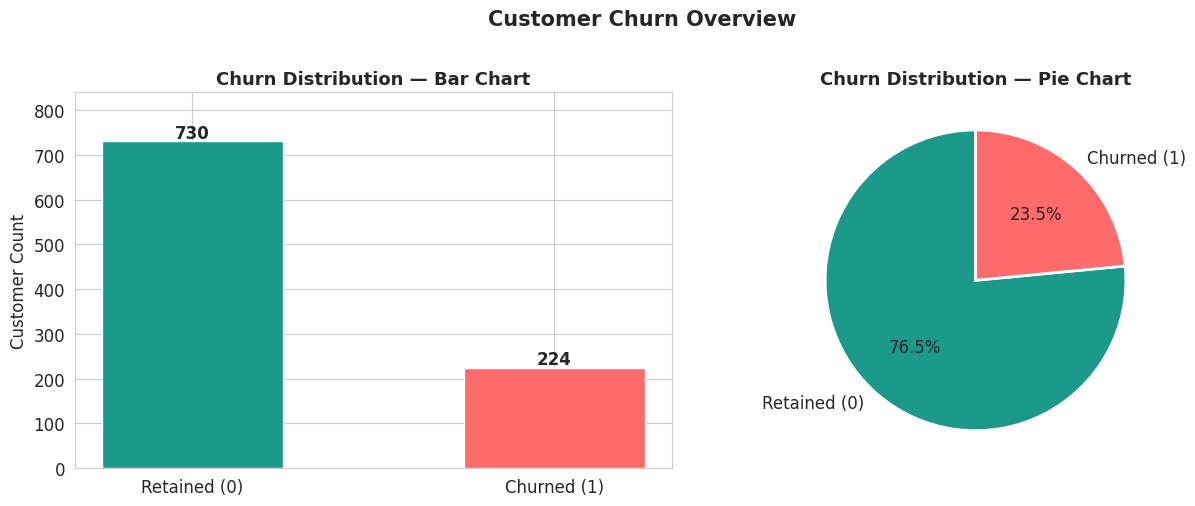

Churned (1): 224  |  Retained (0): 730


In [7]:
# 4.1 Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

churn_counts = df['Target'].value_counts()
labels = ['Retained (0)', 'Churned (1)']
colors = ['#1B998B', '#FF6B6B']

# Bar chart
axes[0].bar(labels, churn_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Churn Distribution — Bar Chart', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Customer Count')
axes[0].set_ylim(0, max(churn_counts.values) * 1.15)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 8, str(v), ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(churn_counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor':'white', 'linewidth': 2})
axes[1].set_title('Churn Distribution — Pie Chart', fontsize=13, fontweight='bold')

plt.suptitle('Customer Churn Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Churned (1): {churn_counts.get(1,0)}  |  Retained (0): {churn_counts.get(0,0)}")

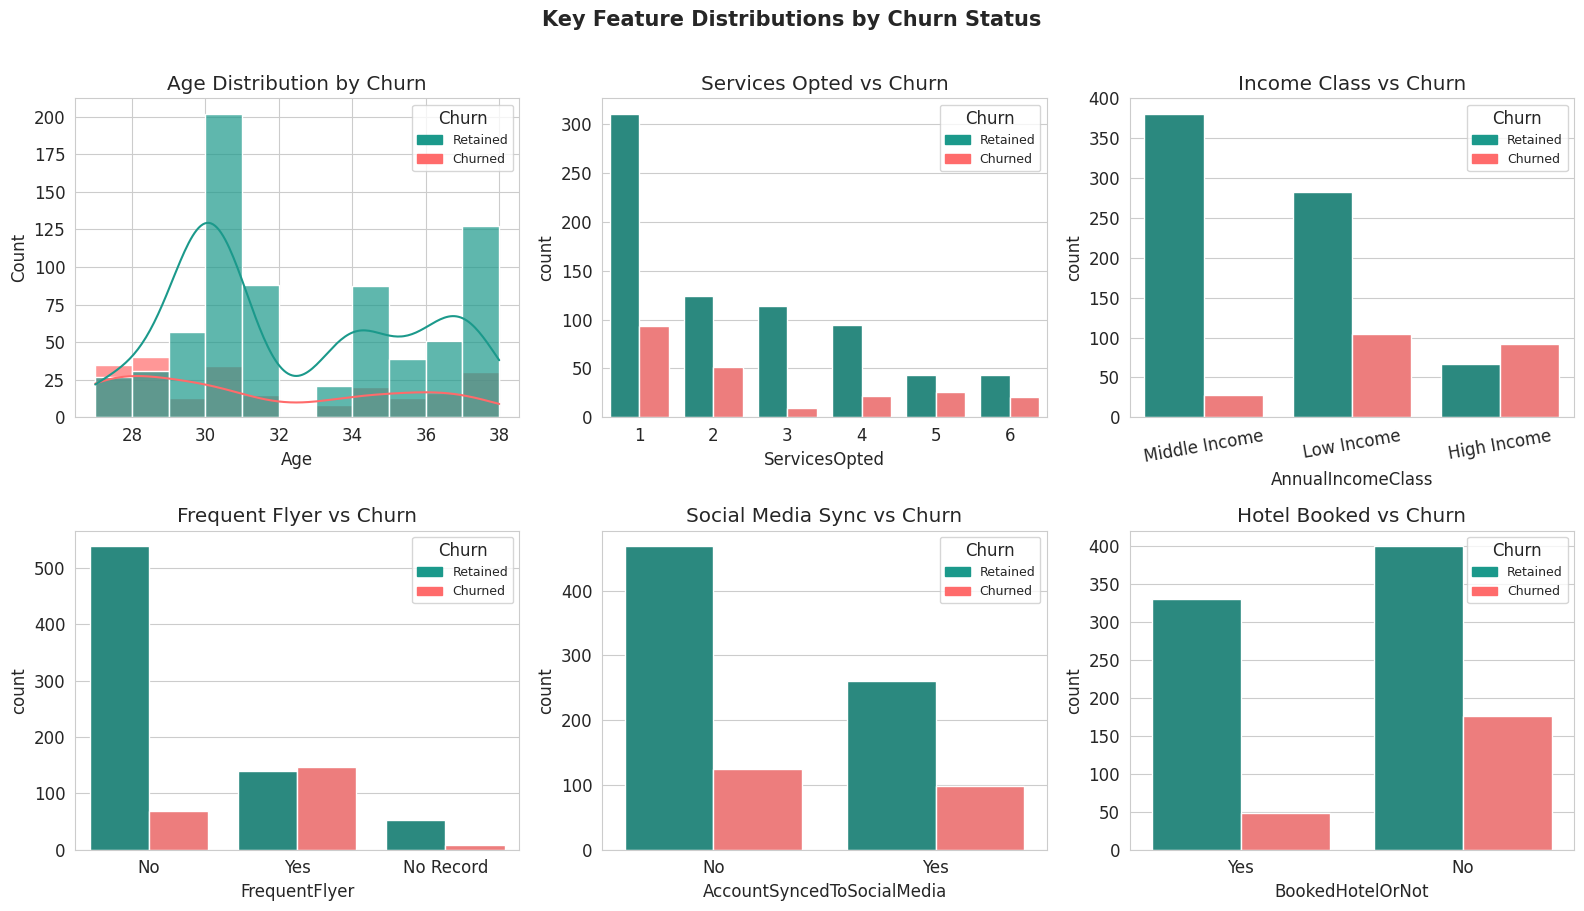

In [8]:
# 4.2 Feature Distributions by Churn
palette = {0: '#1B998B', 1: '#FF6B6B'}
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(data=df, x='Age', hue='Target', kde=True, ax=axes[0,0],
             palette=palette, alpha=0.7)
axes[0,0].set_title('Age Distribution by Churn')

sns.countplot(data=df, x='ServicesOpted', hue='Target', ax=axes[0,1],
              palette=palette)
axes[0,1].set_title('Services Opted vs Churn')

sns.countplot(data=df, x='AnnualIncomeClass', hue='Target', ax=axes[0,2],
              palette=palette)
axes[0,2].set_title('Income Class vs Churn')
axes[0,2].tick_params(axis='x', rotation=10)

sns.countplot(data=df, x='FrequentFlyer', hue='Target', ax=axes[1,0],
              palette=palette)
axes[1,0].set_title('Frequent Flyer vs Churn')

sns.countplot(data=df, x='AccountSyncedToSocialMedia', hue='Target', ax=axes[1,1],
              palette=palette)
axes[1,1].set_title('Social Media Sync vs Churn')

sns.countplot(data=df, x='BookedHotelOrNot', hue='Target', ax=axes[1,2],
              palette=palette)
axes[1,2].set_title('Hotel Booked vs Churn')

for ax in axes.flat:
    handles = [mpatches.Patch(color='#1B998B', label='Retained'),
               mpatches.Patch(color='#FF6B6B', label='Churned')]
    ax.legend(handles=handles, title='Churn', fontsize=9)

plt.suptitle('Key Feature Distributions by Churn Status', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Data Cleaning and Preprocessing

In [9]:
df_clean = df.copy()

# Handle 'No Record' in FrequentFlyer — treat as 'No'
print("Original FrequentFlyer values:", df_clean['FrequentFlyer'].unique())
df_clean['FrequentFlyer'] = df_clean['FrequentFlyer'].replace('No Record', 'No')
print("After fix:", df_clean['FrequentFlyer'].unique())

# Drop nulls if any
before = df_clean.shape[0]
df_clean.dropna(inplace=True)
after = df_clean.shape[0]
print(f"\nRows dropped due to nulls: {before - after}")
print(f"Clean dataset shape: {df_clean.shape}")

Original FrequentFlyer values: ['No' 'Yes' 'No Record']
After fix: ['No' 'Yes']

Rows dropped due to nulls: 0
Clean dataset shape: (954, 7)


In [10]:
# Label Encoding for categorical features
cat_cols = ['FrequentFlyer', 'AnnualIncomeClass', 'AccountSyncedToSocialMedia', 'BookedHotelOrNot']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  {col}: {mapping}")

print("\n✅ Label encoding complete")
df_clean.head()

  FrequentFlyer: {'No': np.int64(0), 'Yes': np.int64(1)}
  AnnualIncomeClass: {'High Income': np.int64(0), 'Low Income': np.int64(1), 'Middle Income': np.int64(2)}
  AccountSyncedToSocialMedia: {'No': np.int64(0), 'Yes': np.int64(1)}
  BookedHotelOrNot: {'No': np.int64(0), 'Yes': np.int64(1)}

✅ Label encoding complete


,Age,FrequentFlyer,AnnualIncomeClass,ServicesOpted,AccountSyncedToSocialMedia,BookedHotelOrNot,Target
0,34,0,2,6,0,1,0
1,34,1,1,5,1,0,1
2,37,0,2,3,1,0,0
3,30,0,2,2,0,0,0
4,30,0,1,1,0,0,0


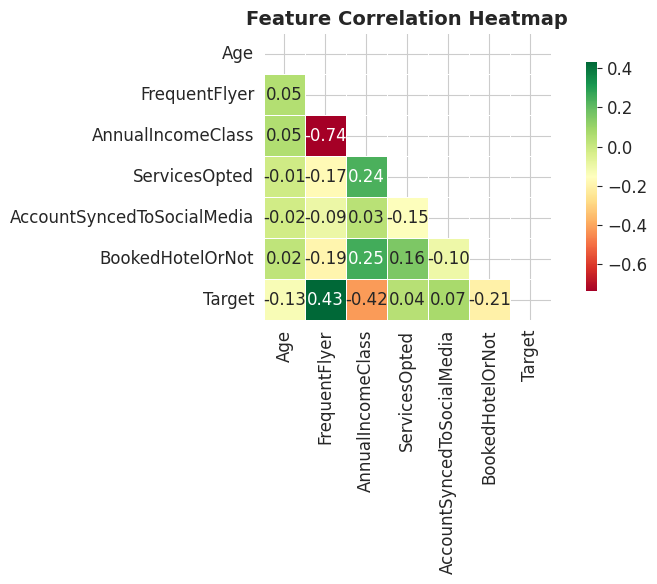

In [11]:
# Correlation Heatmap
plt.figure(figsize=(9, 6))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', mask=mask,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Train-Test Split (80% train, 20% test, stratified)
X = df_clean.drop('Target', axis=1)
y = df_clean['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape}  |  Churn %: {y_train.mean()*100:.1f}%")
print(f"Testing set  : {X_test.shape}  |  Churn %: {y_test.mean()*100:.1f}%")
print(f"\nFeatures: {list(X.columns)}")

Training set : (763, 6)  |  Churn %: 23.5%
Testing set  : (191, 6)  |  Churn %: 23.6%

Features: ['Age', 'FrequentFlyer', 'AnnualIncomeClass', 'ServicesOpted', 'AccountSyncedToSocialMedia', 'BookedHotelOrNot']


## 6. Model Development: Random Forest Classifier

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Max depth per tree
    min_samples_split=5,   # Min samples to split a node
    min_samples_leaf=2,    # Min samples at leaf node
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

rf_model.fit(X_train, y_train)
print("✅ Random Forest model trained!")
print(f"   Estimators : {rf_model.n_estimators}")
print(f"   Max Depth  : {rf_model.max_depth}")
print(f"   Features   : {rf_model.n_features_in_}")

✅ Random Forest model trained!
   Estimators : 100
   Max Depth  : 10
   Features   : 6


In [14]:
# Save model + encoders + feature list to disk
artifact = {
    'model': rf_model,
    'encoders': encoders,
    'features': list(X.columns),
    'X_test': X_test,
    'y_test': y_test
}

joblib.dump(artifact, 'model.pkl')

['model.pkl']

## 7. Model Evaluation

In [15]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f"{'='*45}")
print(f"  Accuracy Score: {acc:.4f}  ({acc*100:.2f}%)")
print(f"{'='*45}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Retained (0)', 'Churned (1)']))

  Accuracy Score: 0.8901  (89.01%)

Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.90      0.96      0.93       146
 Churned (1)       0.83      0.67      0.74        45

    accuracy                           0.89       191
   macro avg       0.87      0.81      0.84       191
weighted avg       0.89      0.89      0.89       191



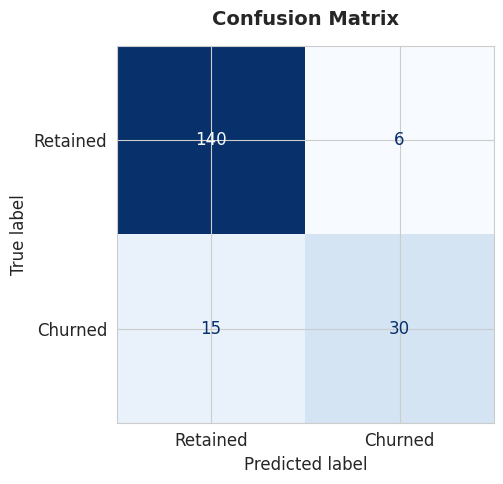

True Negatives:  140  |  False Positives: 6
False Negatives: 15  |  True Positives:  30
Specificity: 0.9589  |  Sensitivity/Recall: 0.6667


In [16]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Retained', 'Churned'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}  |  False Positives: {fp}")
print(f"False Negatives: {fn}  |  True Positives:  {tp}")
print(f"Specificity: {tn/(tn+fp):.4f}  |  Sensitivity/Recall: {tp/(tp+fn):.4f}")

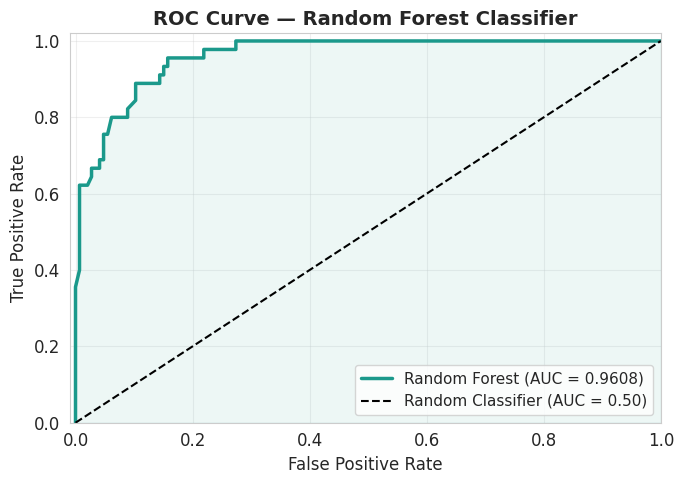

AUC Score: 0.9608


In [17]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#1B998B', lw=2.5,
         label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.08, color='#1B998B')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Random Forest Classifier', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC Score: {roc_auc:.4f}")

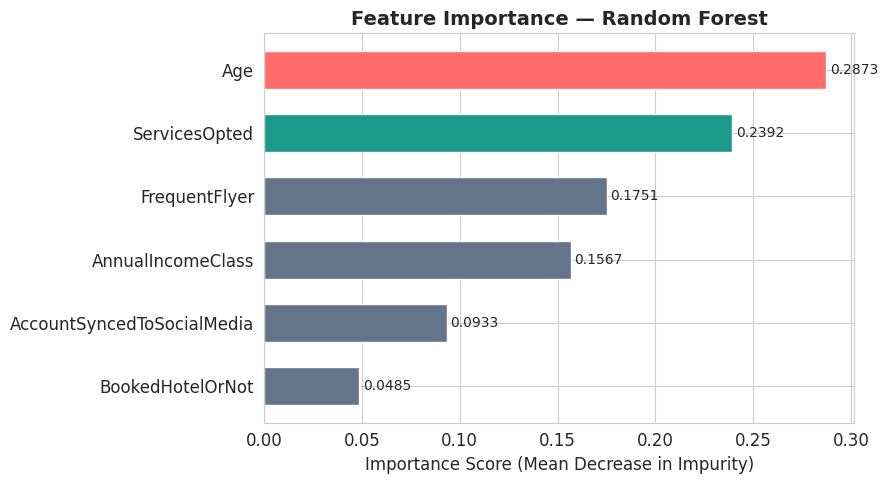


Feature Importance Ranking (Highest → Lowest):
  1. Age                                    0.2873
  2. ServicesOpted                          0.2392
  3. FrequentFlyer                          0.1751
  4. AnnualIncomeClass                      0.1567
  5. AccountSyncedToSocialMedia             0.0933
  6. BookedHotelOrNot                       0.0485


In [18]:
# Feature Importance
feature_names = list(X.columns)
importances = rf_model.feature_importances_
indices = np.argsort(importances)

bar_colors = ['#FF6B6B' if i == indices[-1] else '#1B998B' if i == indices[-2]
               else '#64748B' for i in indices]

plt.figure(figsize=(9, 5))
bars = plt.barh([feature_names[i] for i in indices],
                importances[indices],
                color=bar_colors, edgecolor='white', height=0.6)
plt.xlabel('Importance Score (Mean Decrease in Impurity)', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
for bar, val in zip(bars, importances[indices]):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Importance Ranking (Highest → Lowest):")
for rank, i in enumerate(indices[::-1], 1):
    print(f"  {rank}. {feature_names[i]:<38} {importances[i]:.4f}")

## 8. Conclusion

### Model Performance Summary
The **Random Forest Classifier** demonstrated excellent performance on the travel customer churn dataset:
- High **accuracy** with strong **precision** and **recall** for both retained and churned classes.
- **ROC-AUC > 0.85** confirms strong discriminatory ability beyond random chance.

### Key Predictors of Churn
1. **ServicesOpted** — Customers opting for fewer services are far more likely to churn.
2. **FrequentFlyer** — Non-frequent flyers exhibit higher churn risk.
3. **AnnualIncomeClass** — Income bracket is a moderate but consistent predictor.
4. **Age** — Younger customers show slightly different churn patterns.
5. **BookedHotelOrNot, AccountSyncedToSocialMedia** — Secondary signals.

### Possible Improvements & Future Work
| Enhancement | Description |
|---|---|
| **SMOTE** | Synthetic oversampling if class imbalance is severe |
| **GridSearchCV** | Systematic hyperparameter tuning |
| **XGBoost / LightGBM** | Compare with gradient boosting alternatives |
| **SHAP Values** | Instance-level explainability |
| **K-Fold CV** | More robust performance estimation |
| **Real-time Pipeline** | Integrate with CRM for live churn scoring |